In [1]:
epochs = 5000                                                                   # 학습회수
earlyStopCount = 500                                                            # 조기 종료
learning_rate = 0.001                                                            # 학습율


['N_251124_08.png', 'N_251124_28.png', 'N_251124_25.png', 'N_251124_14.png', 'N_251124_21.png', 'N_251124_04.png', 'N_251124_18.png', 'N_251124_24.png', 'N_251124_29.png', 'N_251124_26.png', 'N_251124_07.png', 'N_251124_27.png']


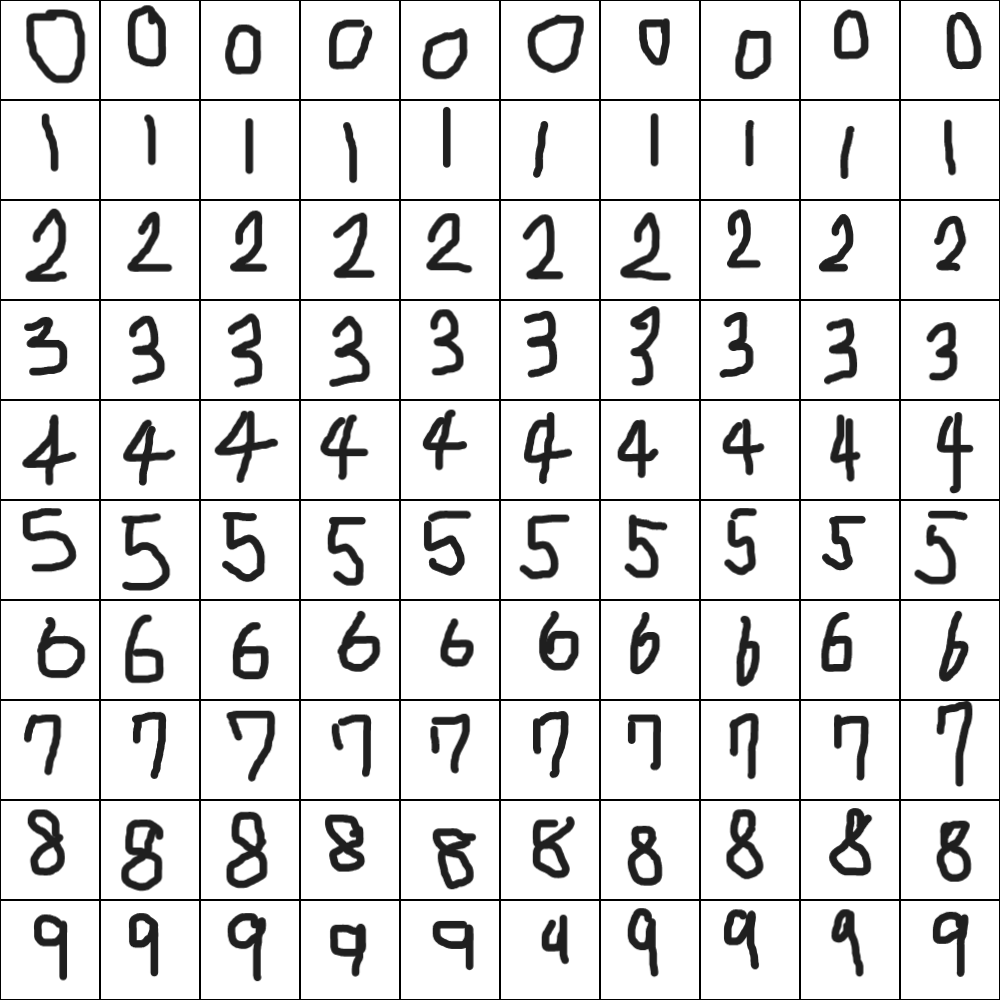

N_251124_08.png



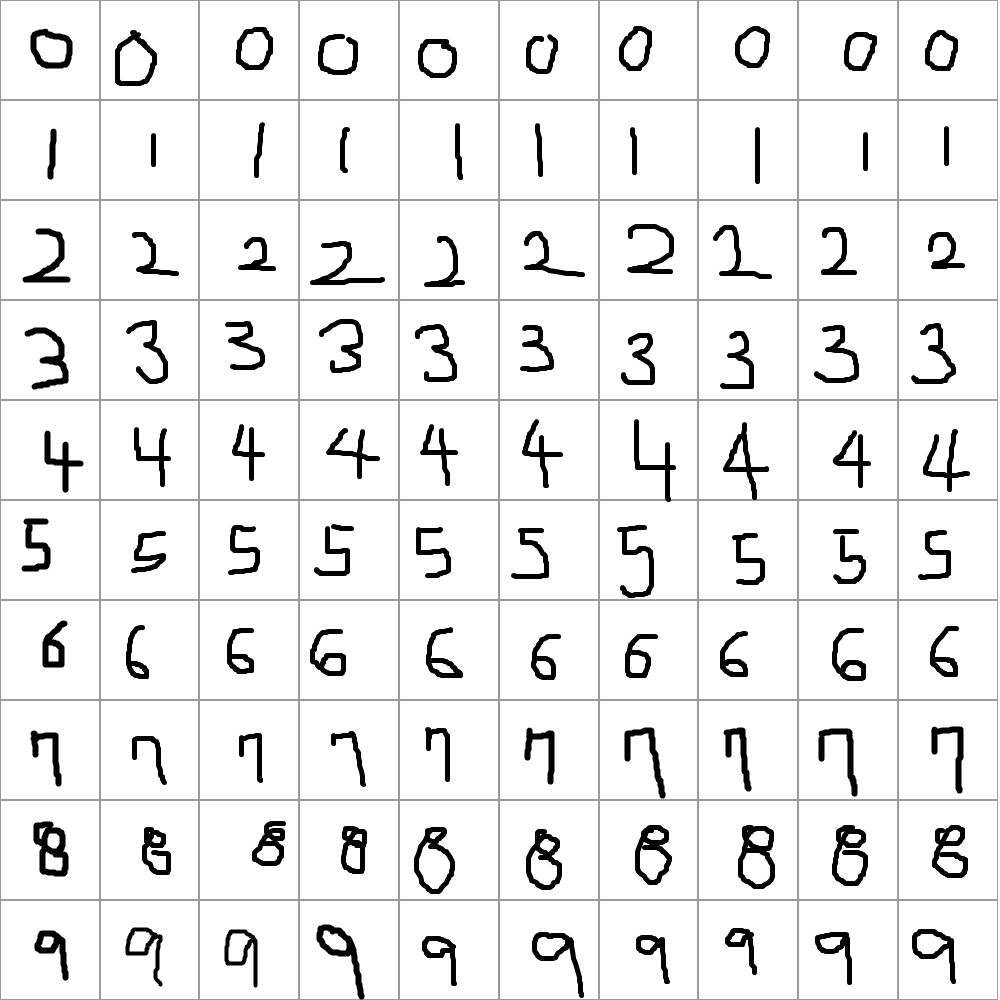

N_251124_28.png



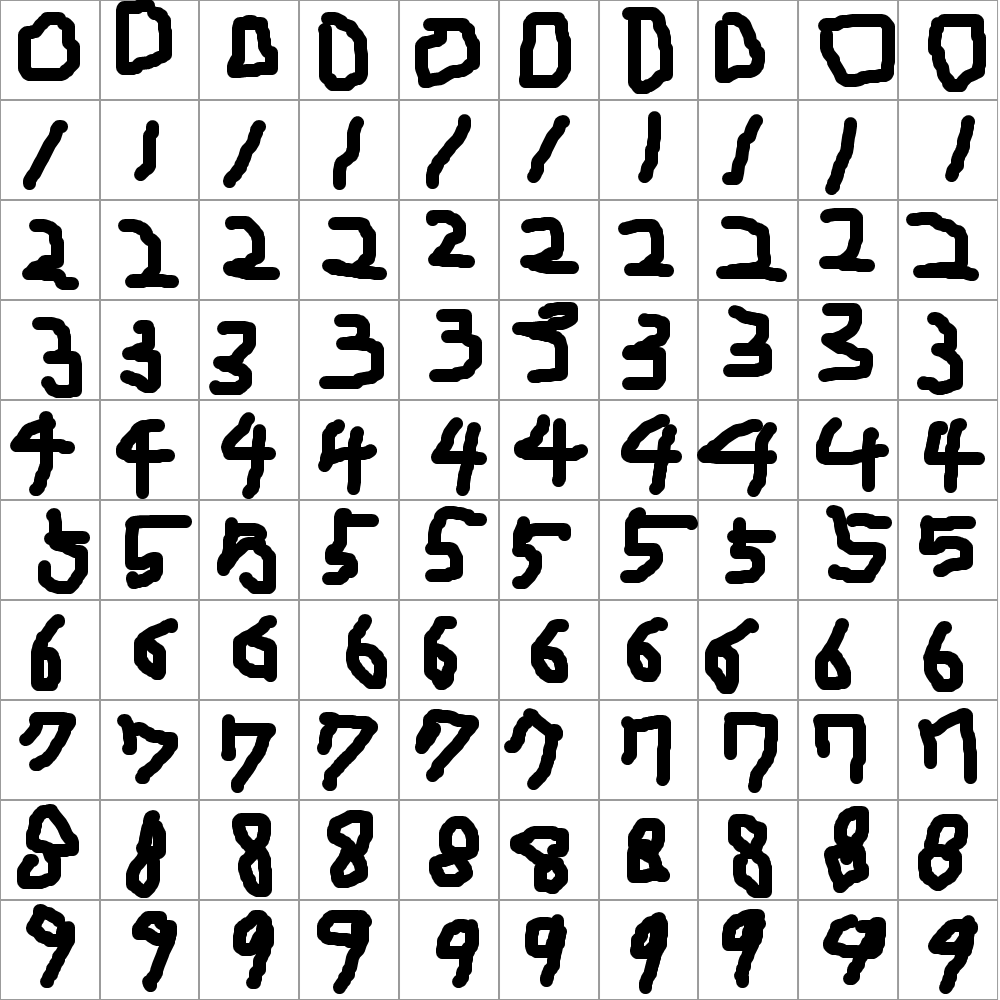

N_251124_25.png



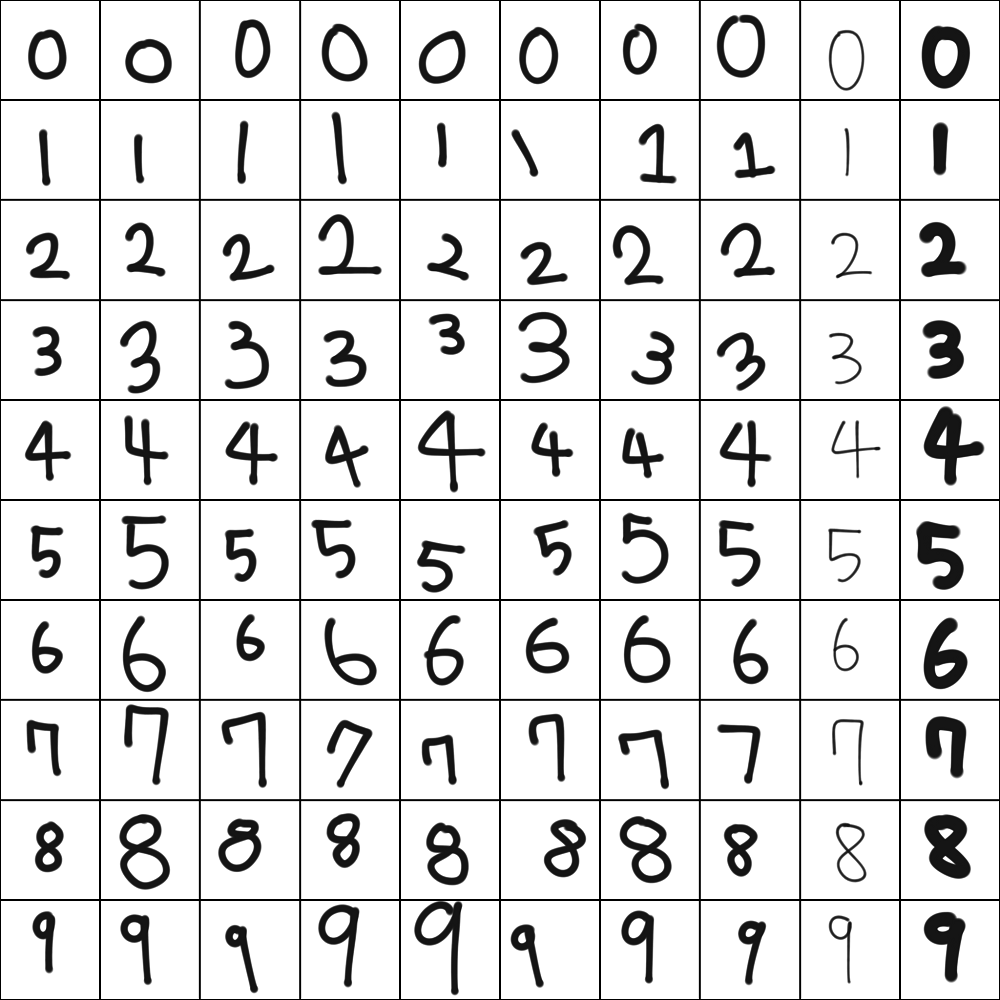

N_251124_14.png



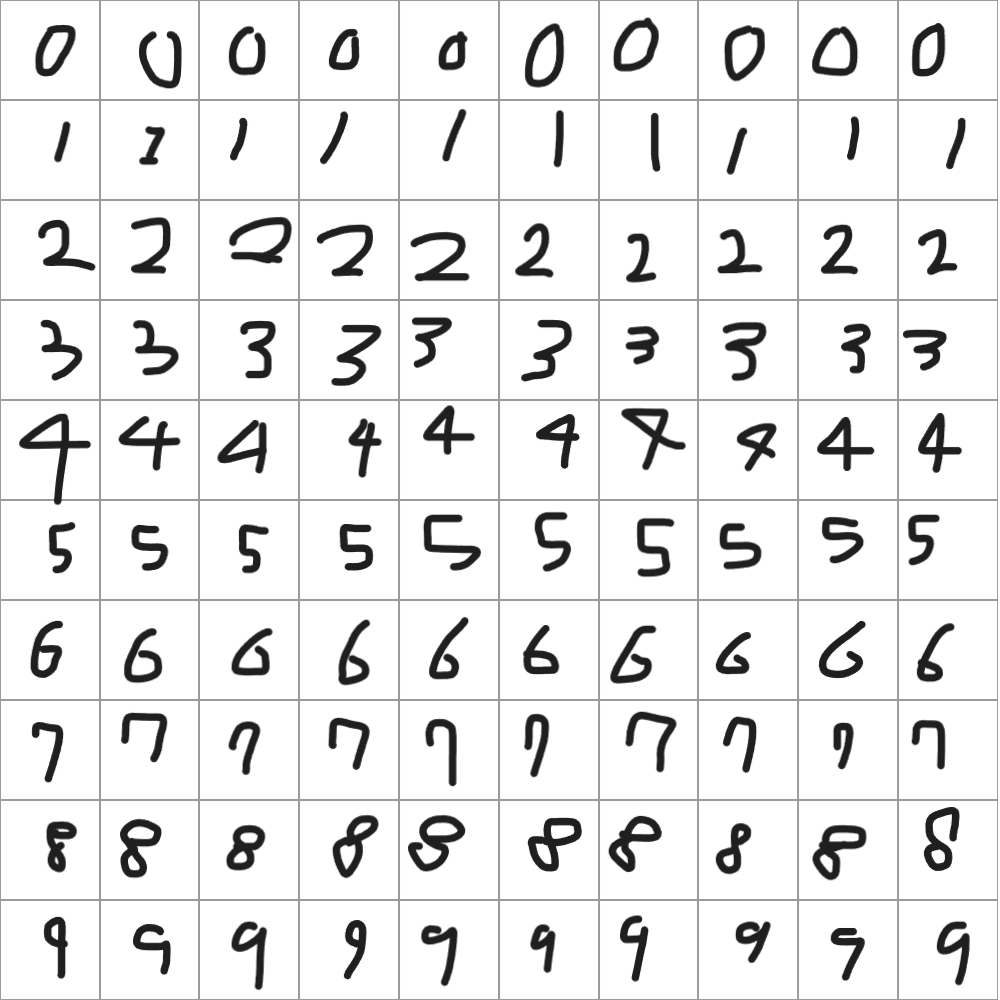

N_251124_21.png



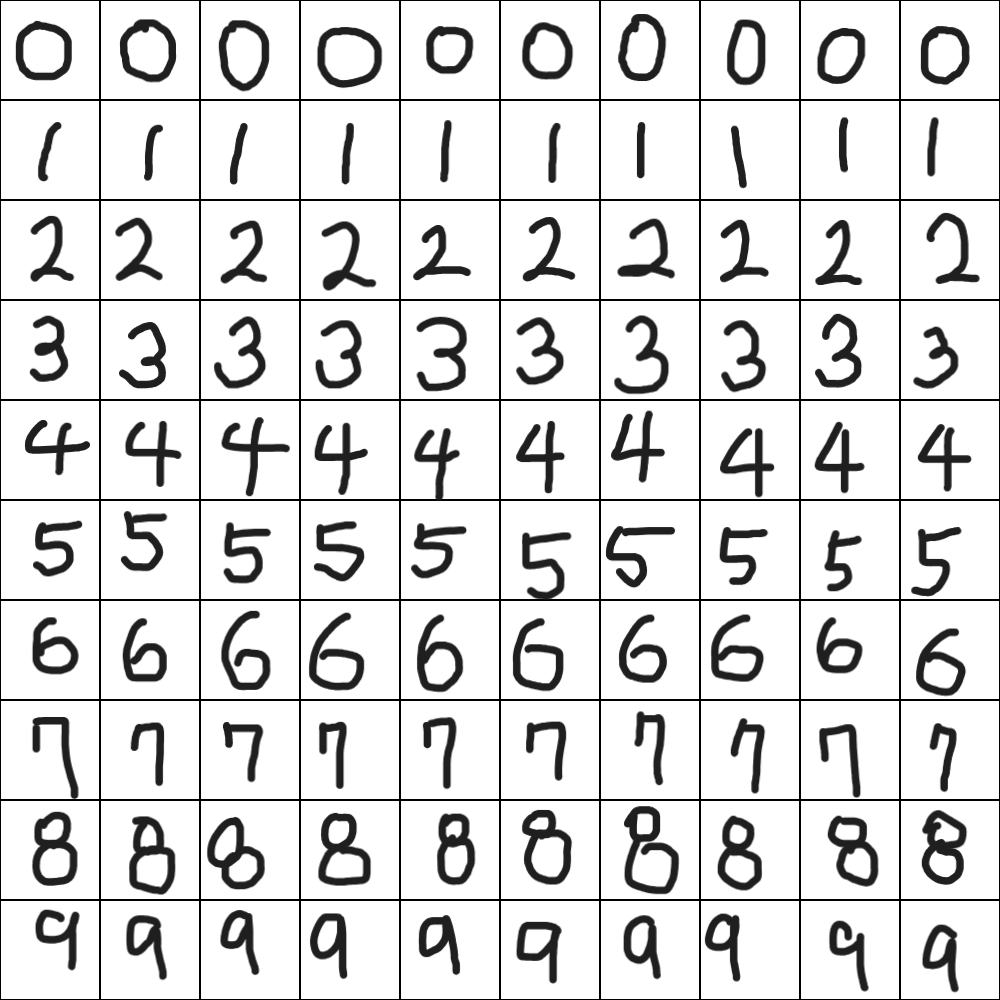

N_251124_04.png



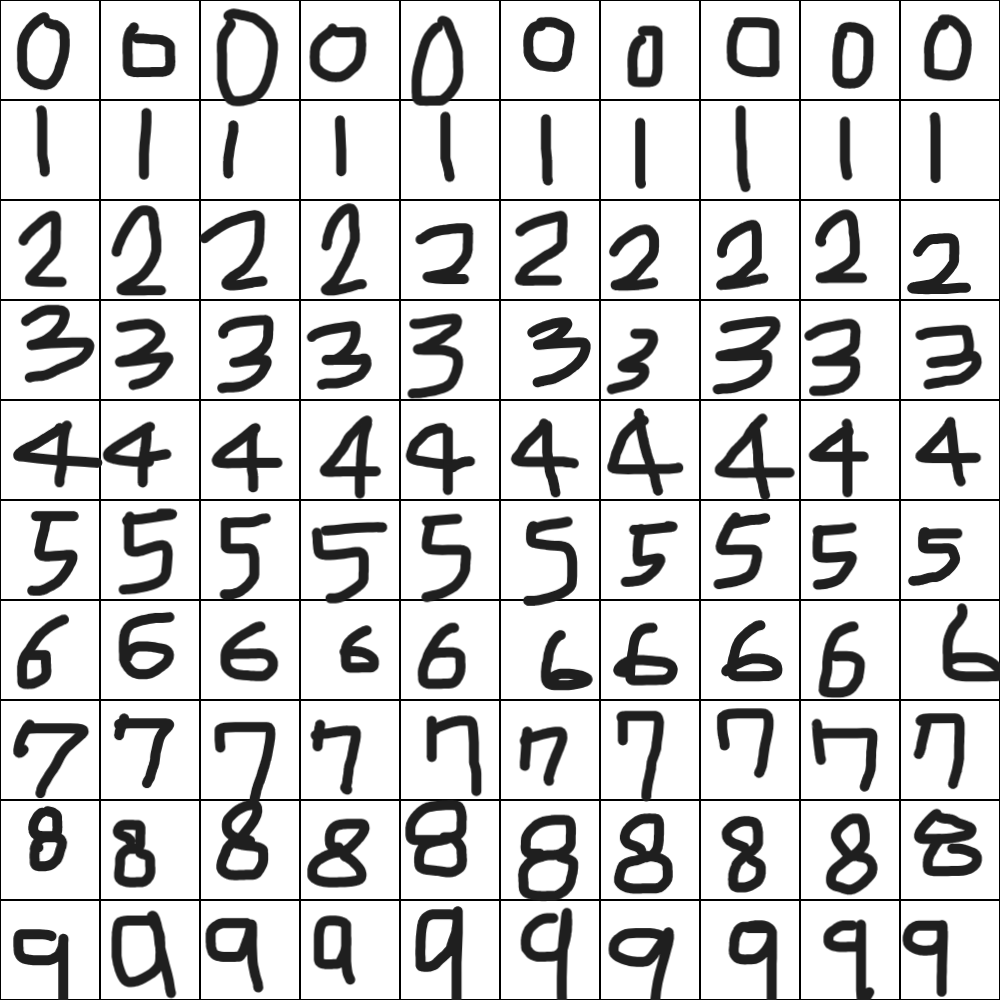

N_251124_18.png



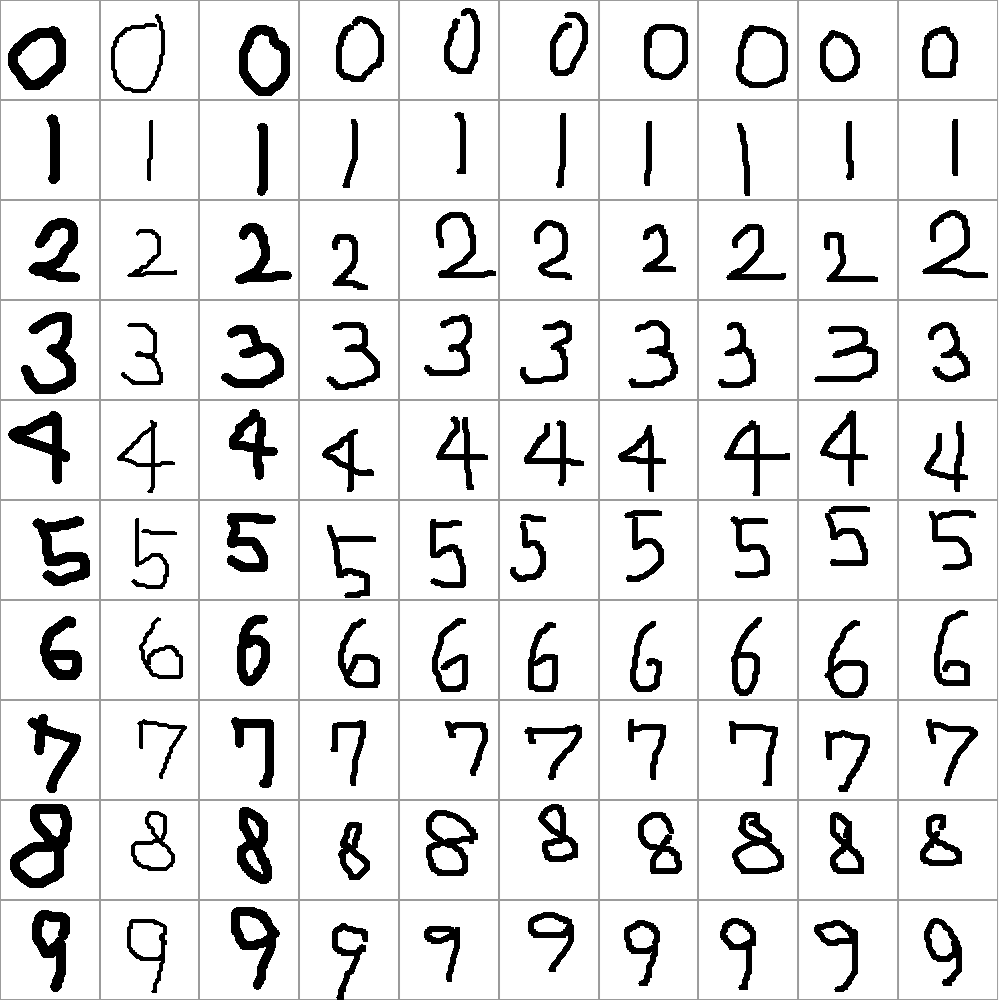

N_251124_24.png



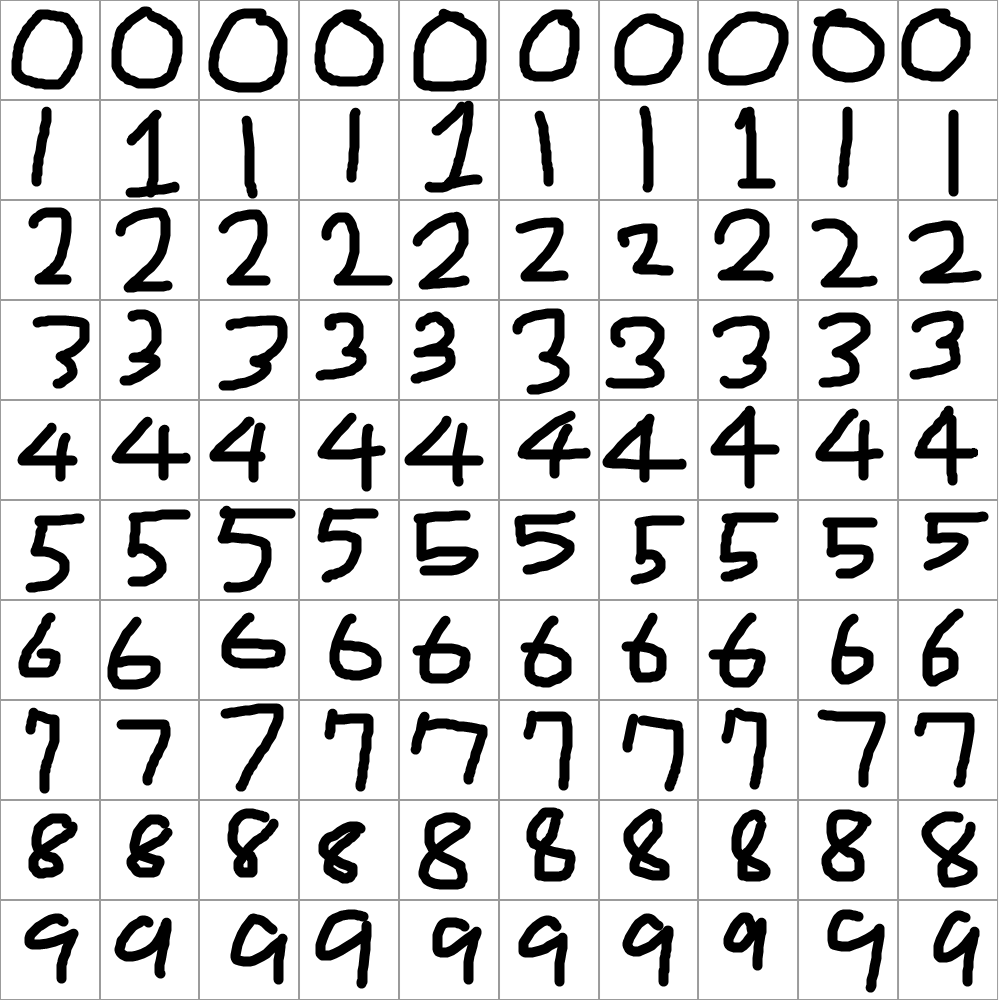

N_251124_29.png



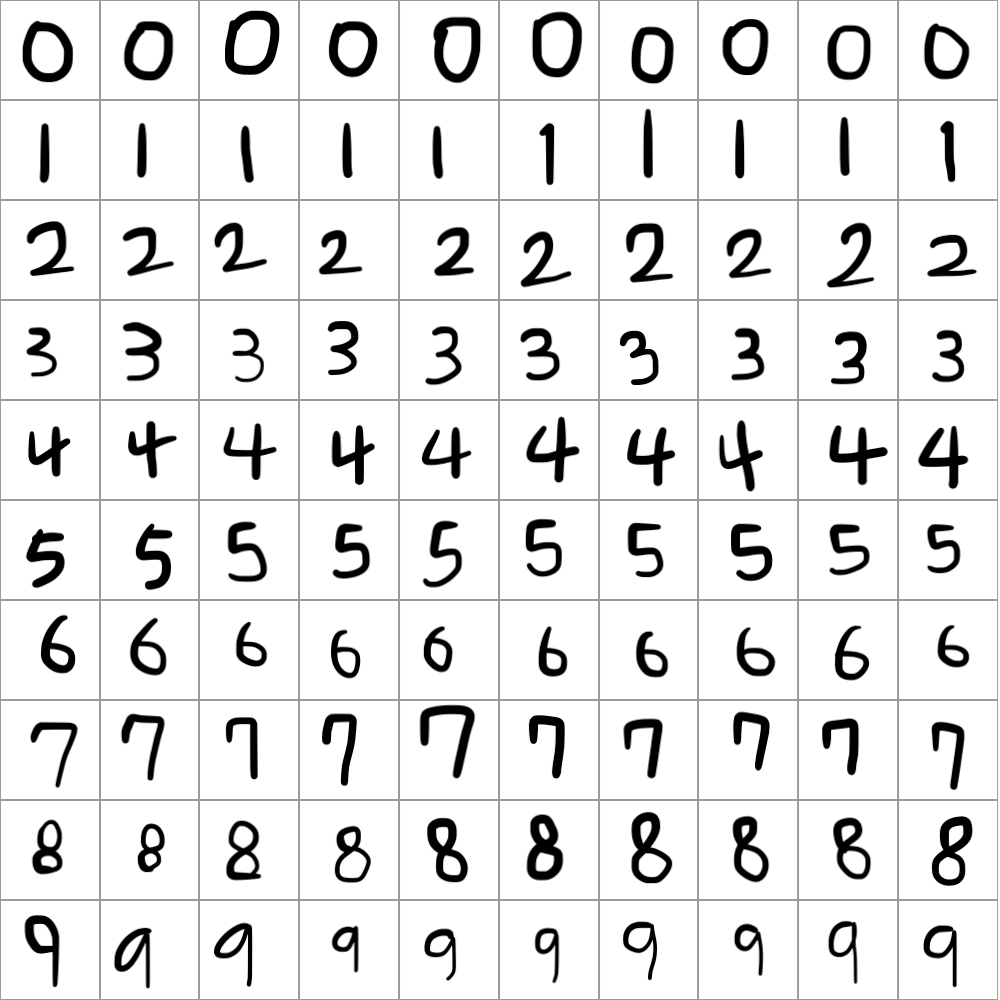

N_251124_26.png



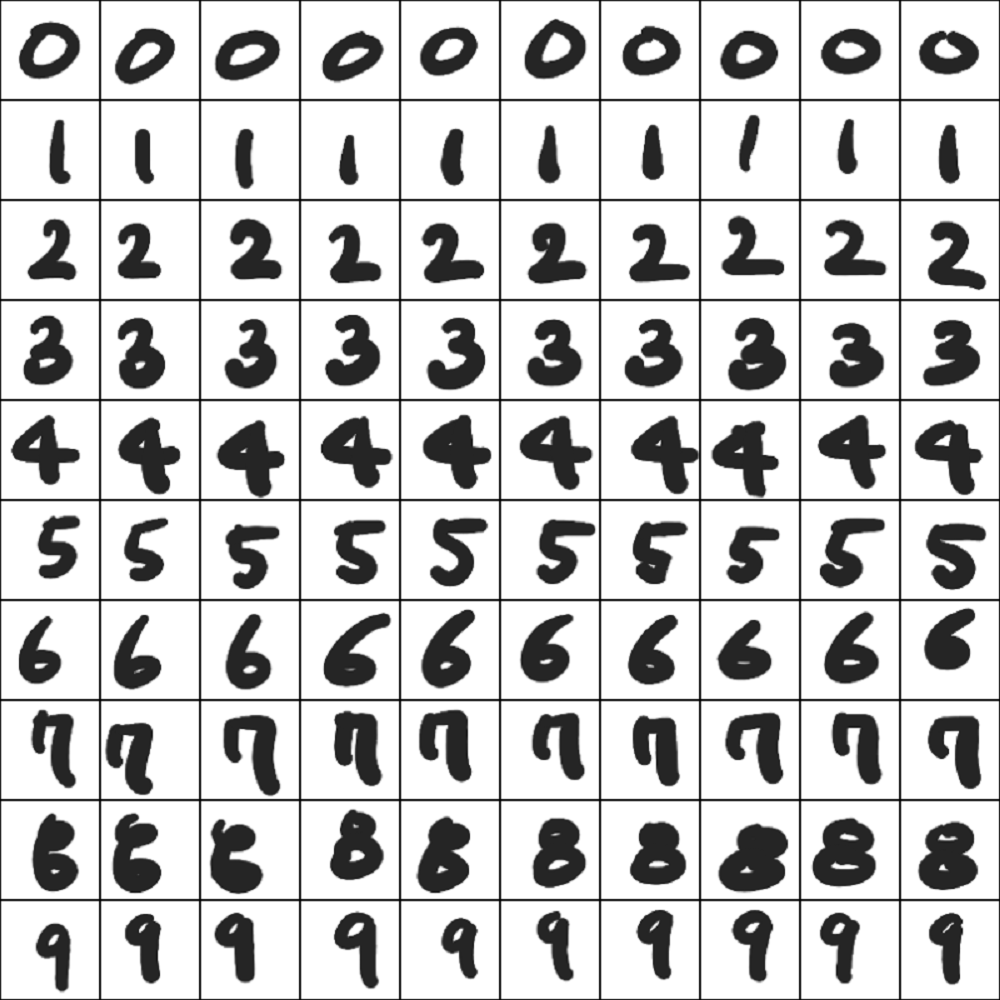

N_251124_07.png



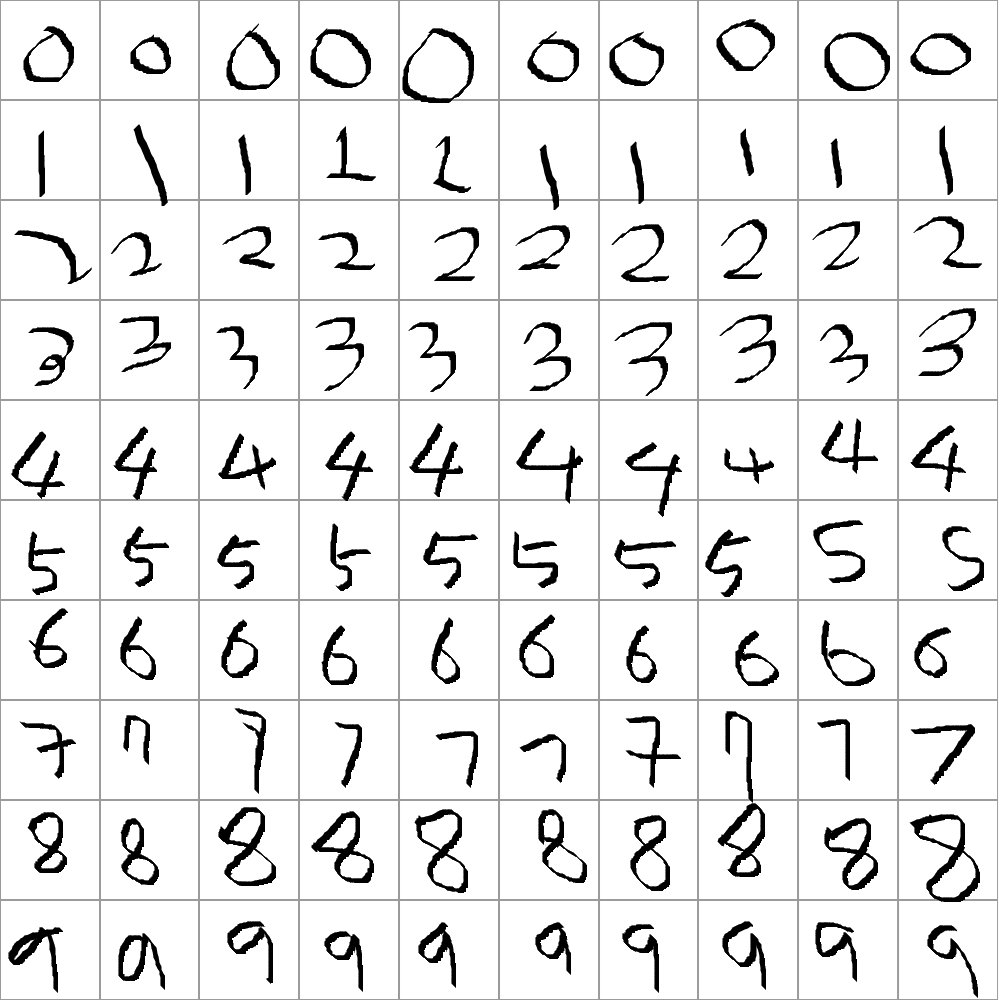

N_251124_27.png



In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import zipfile
import pickle
import random
from google.colab.patches import cv2_imshow # Import cv2_imshow

fileList = glob.glob('N_*.png')
print(fileList)

for fn in fileList:
  img = cv2.imread(fn)
  gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  cv2_imshow(gray_image)
  print(fn)
  print()


In [3]:
TrainImgBatch = []
TrainPosBatch = []
ValidImgBatch = []
ValidPosBatch = []

npos = [
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],     # 0
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],     # 1
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],     # 2
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],     # 3
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],     # 4
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],     # 5
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],     # 6
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],     # 7
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],     # 8
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],     # 9
       ]

rndList = list(range(10))                                                       # 0 부터 9 까지 10 개의 정수 리스트
random.shuffle(rndList)                                                         # 랜덤하게 순서를 섞는다.
print(rndList)
ti = rndList[:8]                                                                # 8 개를 훈련(Train) 데이터로 사용한다.
vi = rndList[8:]                                                                # 2 개를 검증(Valid) 데이터로 사용한다.
print(ti)
print(vi)

for i in range(len(fileList)):

  img = cv2.imread(fileList[i])
  gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  for j in ti:                                                                  # 훈련용 이미지
    for k in range(10):
      image = gray_image[k*100+2:k*100+99-2, j*100+2:j*100+99-2]
      resized_image = cv2.resize(image, (20, 20))                               #
      #cv2.imwrite(f'T{i}_{j}_{k}.png', resized_image)
      normalized_img = resized_image / 255.0                                    # 정규화
      fimage = normalized_img.flatten()                                         # 1 차원으로 직열화 한다.
      TrainImgBatch.append(fimage)
      TrainPosBatch.append(npos[k])

  for j in vi:                                                                  # 검증용 이미지
    for k in range(10):
      image = gray_image[k*100+2:k*100+99-2, j*100+2:j*100+99-2]
      resized_image = cv2.resize(image, (20, 20))                               #
      #cv2.imwrite(f'V{i}_{j}_{k}.png', resized_image)
      normalized_img = resized_image / 255.0                                    # 정규화
      fimage = normalized_img.flatten()                                         # 1 차원으로 직열화 한다.
      ValidImgBatch.append(fimage)
      ValidPosBatch.append(npos[k])

Xt = np.asarray(TrainImgBatch)
Yt = np.asarray(TrainPosBatch)
Xv = np.asarray(ValidImgBatch)
Yv = np.asarray(ValidPosBatch)

print('Len Train Image Batch',len(TrainImgBatch))
print('Len Train Posi  Batch',len(TrainPosBatch))
print('Len Valid Image Batch',len(ValidImgBatch))
print('Len Valid Posi  Batch',len(ValidPosBatch))


[8, 2, 3, 0, 6, 9, 5, 1, 4, 7]
[8, 2, 3, 0, 6, 9, 5, 1]
[4, 7]
Len Train Image Batch 960
Len Train Posi  Batch 960
Len Valid Image Batch 240
Len Valid Posi  Batch 240


In [4]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

class NeuralNetwork:
  def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
    self.input_size = input_size
    self.hidden_size1 = hidden_size1
    self.hidden_size2 = hidden_size2
    self.hidden_size3 = hidden_size3
    self.output_size = output_size

    # 가중치 및 편향 초기화 (He 초기화 사용)
    self.W1 = np.random.randn(self.input_size, self.hidden_size1) * np.sqrt(2 / self.input_size)
    self.B1 = np.zeros((1, self.hidden_size1))
    self.W2 = np.random.randn(self.hidden_size1, self.hidden_size2) * np.sqrt(2 / self.hidden_size1)
    self.B2 = np.zeros((1, self.hidden_size2))
    self.W3 = np.random.randn(self.hidden_size2, self.hidden_size3) * np.sqrt(2 / self.hidden_size2)
    self.B3 = np.zeros((1, self.hidden_size3))
    self.W4 = np.random.randn(self.hidden_size3, self.output_size) * np.sqrt(2 / self.hidden_size3)
    self.B4 = np.zeros((1, self.output_size))

    self.sW1 = np.zeros((self.input_size, self.hidden_size1))
    self.sB1 = np.zeros((1, self.hidden_size1))
    self.sW2 = np.zeros((self.hidden_size1, self.hidden_size2))
    self.sB2 = np.zeros((1, self.hidden_size2))
    self.sW3 = np.zeros((self.hidden_size2, self.hidden_size3))
    self.sB3 = np.zeros((1, self.hidden_size3))
    self.sW4 = np.zeros((self.hidden_size3, self.output_size))
    self.sB4 = np.zeros((1, self.output_size))

  def forward(self, X, Y=None):
    # 순전파 계산
    self.Z1 = np.dot(X, self.W1) + self.B1
    self.A1 = sigmoid(self.Z1)                                                  #
    self.Z2 = np.dot(self.A1, self.W2) + self.B2
    self.A2 = sigmoid(self.Z2)                                                  #
    self.Z3 = np.dot(self.A2, self.W3) + self.B3
    self.A3 = sigmoid(self.Z3)                                                  #
    self.Z4 = np.dot(self.A3, self.W4) + self.B4
    self.Y_hat = sigmoid(self.Z4)                                               #

    # Calculate error if Y is provided
    if Y is not None:
      error = np.mean((self.Y_hat - Y)**2)                                      # Mean Squared Error
    else:
      error = None

    return self.Y_hat, error                                                    # Return both Y_hat and error

  def backward(self, X, Y, learning_rate):
    # 역전파 계산
    # M x N 행열과 N x P 행열의 곱셈은 M x P 행열이 되며 앞의 행열의 열의(N) 개수와 뒤 행열의 행(N)의 개수가 같아야 한다.
                                                              #

    D4 = (self.Y_hat - Y) * sigmoid_derivative(self.Z4)       #
    dW4 = np.dot(self.A3.T, D4)                               #
    dB4 = np.sum(D4, axis=0, keepdims=True)                   #

    D3 = np.dot(D4, self.W4.T) * sigmoid_derivative(self.Z3)  #
    dW3 = np.dot(self.A2.T, D3)                               #
    dB3 = np.sum(D3, axis=0, keepdims=True)                   #

    D2 = np.dot(D3, self.W3.T) * sigmoid_derivative(self.Z2)  #
    dW2 = np.dot(self.A1.T, D2)                               #
    dB2 = np.sum(D2, axis=0, keepdims=True)                   #

    D1 = np.dot(D2, self.W2.T) * sigmoid_derivative(self.Z1)  #
    dW1 = np.dot(X.T, D1)                                     #
    dB1 = np.sum(D1, axis=0, keepdims=True)                   #

    # 가중치 및 편향 업데이트
    self.W4 -= learning_rate * dW4
    self.B4 -= learning_rate * dB4
    self.W3 -= learning_rate * dW3
    self.B3 -= learning_rate * dB3
    self.W2 -= learning_rate * dW2
    self.B2 -= learning_rate * dB2
    self.W1 -= learning_rate * dW1
    self.B1 -= learning_rate * dB1

  def train(self, Xt, Yt, Xv, Yv, epochs, learning_rate):
    Terrors = []
    Verrors = []
    earlyStop = 0
    previousTError = float('inf')
    previousVError = float('inf')

    for i in range(epochs):
      Y_hat, tError = self.forward(Xt, Yt)                                      # Pass both X and y to forward
      Terrors.append(tError)
      self.backward(Xt, Yt, learning_rate)                                      # 가중치 W, 바이어스 b 업데이트

      _, vError = self.forward(Xv, Yv)                                          # 검증용 데이터 에러 계산
      Verrors.append(vError)
      print(f"Epoch {i+1}/{epochs}  Training Loss: {tError:.16f}  Validation Loss: {vError:.16f}")
      if vError < previousVError:
        earlyStop = 0
        previousVError = vError
        previousTError = tError
        # 학습 결과가 개선 되었으면 W, b 값 보관
        self.sW1 = self.W1; self.sB1 = self.B1
        self.sW2 = self.W2; self.sB2 = self.B2
        self.sW3 = self.W3; self.sB3 = self.B3
        self.sW4 = self.W4; self.sB4 = self.B4
      else:
        earlyStop += 1
        print(f"----- Early stopping {earlyStop}/{earlyStopCount}")
        if earlyStop >= earlyStopCount:
          print("Early stopping triggered")
          break

    # 보관된 학습 결과 복원
    self.W1 = self.sW1; self.B1 = self.sB1
    self.W2 = self.sW2; self.B2 = self.sB2
    self.W3 = self.sW3; self.B3 = self.sB3
    self.W4 = self.sW4; self.B4 = self.sB4

    return Terrors, Verrors, previousTError, previousVError

  def saveWeightBias(self, fileName):
    with open(fileName, 'wb') as f:
      pickle.dump(self.W1, f)
      pickle.dump(self.B1, f)
      pickle.dump(self.W2, f)
      pickle.dump(self.B2, f)
      pickle.dump(self.W3, f)
      pickle.dump(self.B3, f)
      pickle.dump(self.W4, f)
      pickle.dump(self.B4, f)


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Epoch 2487/5000  Training Loss: 0.0648184759812065  Validation Loss: 0.0699246666070331
----- Early stopping 26/500
Epoch 2488/5000  Training Loss: 0.0611723925814118  Validation Loss: 0.0629809302141905
----- Early stopping 27/500
Epoch 2489/5000  Training Loss: 0.0541985988963652  Validation Loss: 0.0618291717164145
Epoch 2490/5000  Training Loss: 0.0532064455588409  Validation Loss: 0.0621616415749890
----- Early stopping 1/500
Epoch 2491/5000  Training Loss: 0.0528568301693832  Validation Loss: 0.0617670698722015
Epoch 2492/5000  Training Loss: 0.0530393441518234  Validation Loss: 0.0631989866843203
----- Early stopping 1/500
Epoch 2493/5000  Training Loss: 0.0536274964058989  Validation Loss: 0.0639100660925134
----- Early stopping 2/500
Epoch 2494/5000  Training Loss: 0.0552645609062868  Validation Loss: 0.0658585766327755
----- Early stopping 3/500
Epoch 2495/5000  Training Loss: 0.0565968939301959  Validation Loss: 0.0665898893861685
----- Ea

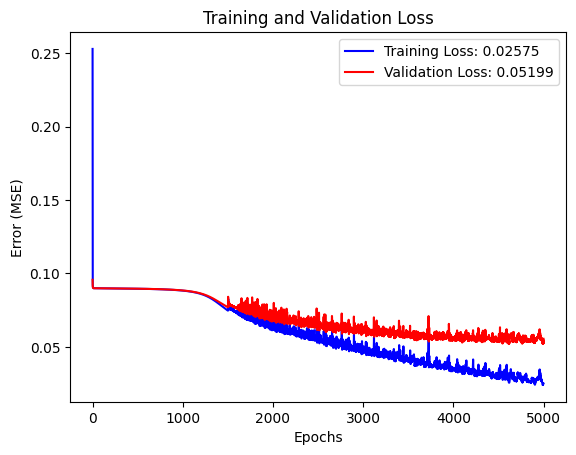

In [5]:
# 신경망 객체 생성
nn = NeuralNetwork(400, 200, 100, 50, 10)

print('Xt', Xt.shape); print('Yt', Yt.shape); print('Xv', Xv.shape); print('Yv', Yv.shape)

Terrors, Verrors, terror, verror = nn.train(Xt, Yt, Xv, Yv, epochs, learning_rate)              # 학습

plt.plot(Terrors, label = f'Training Loss: {terror:.5f}', color = 'b')
plt.plot(Verrors, label = f'Validation Loss: {verror:.5f}', color = 'r')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Error (MSE)")
plt.title("Training and Validation Loss")
plt.show()


이미지 화일 이름을 입력하고 [ENTER]를 누르세요:0


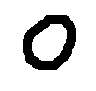

[[0.99 0.   0.   0.   0.   0.02 0.06 0.   0.   0.  ]]
예측 숫자: 0


In [15]:
fileName = input('이미지 화일 이름을 입력하고 [ENTER]를 누르세요:')
img = cv2.imread(fileName+'.png')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_image)
resized_image = cv2.resize(gray_image, (20, 20))                               #
normalized_img = resized_image / 255.0                                    # 정규화
fimage = normalized_img.flatten()                                         # 1 차원으로 직열화 한다.
predictions, _ = nn.forward(fimage)
rounded_predictions = np.round(predictions, 2)                                  # Round to 2 decimal places
print(rounded_predictions)
max_positions = np.argmax(predictions, axis=1)                                  # Find positions of maximum values along each row
print("예측 숫자:", max_positions[0])
